# 4.5 — Diferencias finitas I: esquemas, estabilidad y convergencia

Monte Carlo (4.1-4.4) resuelve el precio como una esperanza; **diferencias finitas** lo resuelve como la solución de la PDE de Black-Scholes directamente, discretizando el operador diferencial sobre una malla en $(S,t)$. Es el tercer pilar del pricing numérico, junto a árboles y Monte Carlo, y el que domina cuando el problema tiene pocas dimensiones espaciales pero necesita el precio en **todo** un rango de $S$ a la vez — exactamente lo que hace falta para griegas por diferencia central sin ruido de simulación, y lo que en 4.6 permitirá tratar la desigualdad variacional de las americanas.

Este notebook resuelve la ecuación de Black-Scholes por tres variantes del mismo esquema — explícito, implícito, Crank-Nicolson — y responde la pregunta que las distingue: ¿bajo qué condiciones el esquema es **estable**, es decir, no amplifica el error en cada paso hasta la explosión? La respuesta, el análisis de von Neumann, es tan importante como cualquier fórmula de pricing: un esquema inestable no da un precio equivocado, da basura numérica, y hay que saber reconocer la frontera exacta entre uno y otro.

## 0. Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
from scipy.stats import norm

from qflib.black import bs_price
from qflib.plotting import apply_style

apply_style()

# Canonical parameters
S0, K, r, q, sigma, T = 100.0, 100.0, 0.05, 0.0, 0.20, 1.0


def bs_call_grid(S, K, r, q, sigma, T):
    '''Vectorized Black-Scholes call, for comparing against a whole PDE grid at once.

    qflib.black.bs_price is scalar-only (forces float(S)); this notebook needs the
    price at every node of S simultaneously, so it broadcasts the same formula
    with norm.cdf over an array instead.
    '''
    S = np.asarray(S, dtype=float)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


print(f"S0={S0}, K={K}, r={r}, q={q}, sigma={sigma}, T={T}")
print(f"Call europeo (referencia exacta) = {bs_price(S0, K, r, q, sigma, T, 'call'):.10f}")
print("Este notebook no usa Monte Carlo -- todo es deterministico, sin rng.")

S0=100.0, K=100.0, r=0.05, q=0.0, sigma=0.2, T=1.0
Call europeo (referencia exacta) = 10.4505835722
Este notebook no usa Monte Carlo -- todo es deterministico, sin rng.


## 1. De la PDE de Black-Scholes a la ecuación de calor

La PDE de 3.1, $\partial_tV+\tfrac12\sigma^2S^2\partial_{SS}V+(r-q)S\partial_SV-rV=0$, tiene coeficientes que dependen de $S$ — una malla uniforme en $S$ sería fina donde no hace falta y gruesa donde sí. El cambio de variable estándar $x=\ln S$ (y $\tau=T-t$, para integrar hacia adelante en $\tau$) elimina esa dependencia: con $V(S,t)=u(x,\tau)$, la regla de la cadena da $\partial_SV=u_x/S$ y $\partial_{SS}V=(u_{xx}-u_x)/S^2$, y sustituyendo,
$$
\partial_\tau u = \frac{\sigma^2}{2}\,\partial_{xx}u \;+\; \Big(r-q-\frac{\sigma^2}{2}\Big)\partial_xu \;-\; r\,u,
$$
una ecuación de **convección-difusión-reacción** con coeficientes constantes: la malla en $x=\ln S$ sí puede ser uniforme, y es donde el problema es homogéneo.

**Discretización.** Con $x_j=x_{\min}+j\Delta x$ y $u_j^n\approx u(x_j,\tau_n)$, el operador espacial se aproxima por diferencias centradas de segundo orden,
$$
Lu_j := a\,u_{j-1} + b\,u_j + c\,u_{j+1}, \qquad
a=\frac{\sigma^2}{2\Delta x^2}-\frac{\nu}{2\Delta x},\quad
b=-\frac{\sigma^2}{\Delta x^2}-r,\quad
c=\frac{\sigma^2}{2\Delta x^2}+\frac{\nu}{2\Delta x},
$$
con $\nu=r-q-\tfrac12\sigma^2$. El **$\theta$-scheme** interpola entre evaluar $L$ en el tiempo viejo o el nuevo:
$$
\frac{u_j^{n+1}-u_j^n}{\Delta\tau} = \theta\,Lu_j^{n+1} + (1-\theta)\,Lu_j^n,
$$
que da $\theta=0$ (**explícito**, $u^{n+1}$ despejado directo), $\theta=1$ (**implícito**, resolver un sistema tridiagonal) y $\theta=\tfrac12$ (**Crank-Nicolson**). Los tres, salvo el explícito, se resuelven con `scipy.linalg.solve_banded` en $O(N)$ por paso — la estructura tridiagonal es la razón de que diferencias finitas escale bien en una dimensión espacial.

**Condiciones de frontera.** Truncamos $x\in[x_{\min},x_{\max}]$ y usamos el comportamiento asintótico exacto de un call europeo: $V\to0$ cuando $S\to0$, y $V\to Se^{-q\tau}-Ke^{-r\tau}$ cuando $S\to\infty$ (la cartera de réplica ya no puede ejercerse anticipadamente en $x_{\max}$, así que el forward domina). Con el dominio suficientemente ancho ($x_{\max}-\ln S_0\gtrsim6\sigma\sqrt T$) el error de truncar ahí es despreciable frente al de la malla.

In [2]:
def theta_scheme_call(Nx, Nt, theta, S0=S0, K=K, r=r, q=q, sigma=sigma, T=T, x_width=6.0, kind="call"):
    '''Solve Black-Scholes by the theta-scheme in x=ln(S), tau=T-t (Section 1).

    theta=0: explicit. theta=1: implicit. theta=0.5: Crank-Nicolson.
    Returns (S_grid, V_grid) at tau=T (i.e. t=0), the whole spatial slice.
    '''
    nu = r - q - 0.5 * sigma**2
    x_min = np.log(S0) - x_width * sigma * np.sqrt(T)
    x_max = np.log(S0) + x_width * sigma * np.sqrt(T)
    dx = (x_max - x_min) / Nx
    dt = T / Nt
    x = np.linspace(x_min, x_max, Nx + 1)
    S = np.exp(x)

    a = 0.5 * sigma**2 / dx**2 - nu / (2 * dx)
    b = -sigma**2 / dx**2 - r
    c = 0.5 * sigma**2 / dx**2 + nu / (2 * dx)
    sign = 1.0 if kind == "call" else -1.0
    V = np.maximum(sign * (S - K), 0.0)              # payoff en tau=0

    n_in = Nx - 1
    ab = np.zeros((3, n_in))                          # matriz implicita banded (solve_banded format)
    ab[0, 1:] = -theta * dt * c                       # superdiagonal
    ab[1, :] = 1.0 - theta * dt * b                   # diagonal
    ab[2, :-1] = -theta * dt * a                      # subdiagonal

    def boundary(tau):
        if kind == "call":
            return 0.0, S[-1] * np.exp(-q * tau) - K * np.exp(-r * tau)
        return K * np.exp(-r * tau) - S[0] * np.exp(-q * tau), 0.0

    for n in range(Nt):
        tau_new = (n + 1) * dt
        V_min_new, V_max_new = boundary(tau_new)
        rhs = ((1 - theta) * dt * a * V[0:n_in] + (1 + (1 - theta) * dt * b) * V[1:n_in + 1]
               + (1 - theta) * dt * c * V[2:n_in + 2])
        rhs[0] += theta * dt * a * V_min_new           # frontera implicita: se conoce, se mueve al RHS
        rhs[-1] += theta * dt * c * V_max_new
        V_interior = solve_banded((1, 1), ab, rhs)
        V = np.concatenate([[V_min_new], V_interior, [V_max_new]])
    return S, V


S_grid, V_implicit = theta_scheme_call(800, 400, theta=1.0)
_, V_cn = theta_scheme_call(800, 400, theta=0.5)
bs_on_grid = bs_call_grid(S_grid, K, r, q, sigma, T)
idx_S0 = np.argmin(np.abs(S_grid - S0))
print(f"En S0={S0}: implicito={V_implicit[idx_S0]:.6f} | CN={V_cn[idx_S0]:.6f} | "
      f"exacto={bs_on_grid[idx_S0]:.6f}")
print(f"error implicito={V_implicit[idx_S0]-bs_on_grid[idx_S0]:+.6f} | "
      f"error CN={V_cn[idx_S0]-bs_on_grid[idx_S0]:+.6f}")

En S0=100.0: implicito=10.447758 | CN=10.450382 | exacto=10.450584
error implicito=-0.002826 | error CN=-0.000201


## 2. Demo 1 — precio en toda la malla, y dónde vive el error

Con $N_x=800$, $N_\tau=400$ resolvemos el call en **todo** el rango de $S$ de una sola corrida — la ventaja frente a Monte Carlo, que da un precio a la vez. Comparamos implícito y Crank-Nicolson contra Black-Scholes nodo por nodo. El error debe concentrarse cerca de $S=K$: ahí el payoff tiene un *kink* (no es $C^2$), y la discretización de segundo orden en espacio pierde precisión exactamente donde la solución no es suave — el mismo fenómeno, en otro disfraz, que el sesgo de discretización de 4.1.

max|error| implicito = 0.00288  (atol objetivo 5e-3)
max|error| CN        = 0.00020  (atol objetivo 5e-3)


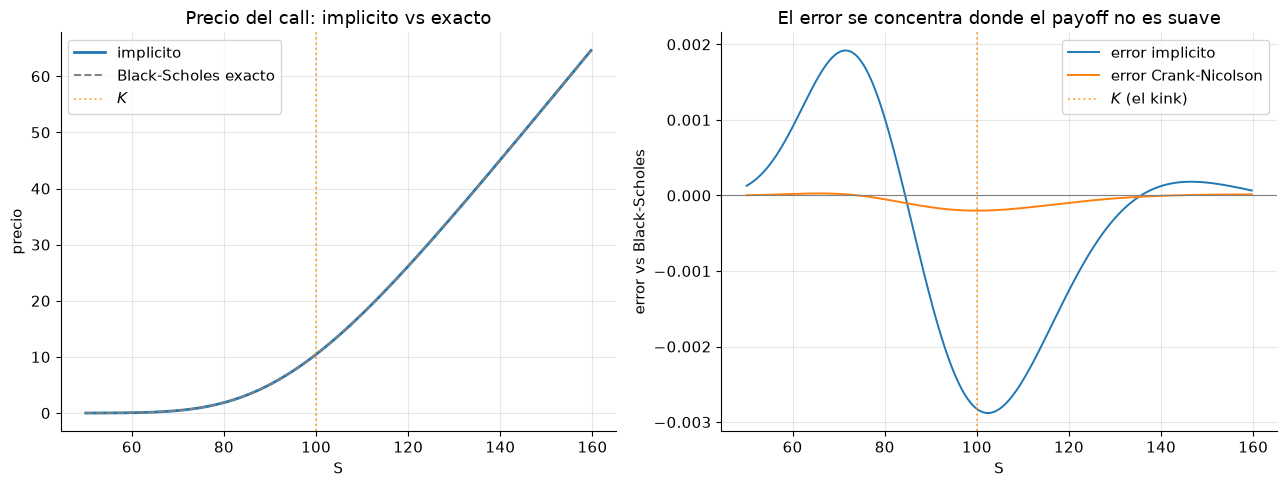

In [3]:
error_implicit = V_implicit - bs_on_grid
error_cn = V_cn - bs_on_grid
print(f"max|error| implicito = {np.max(np.abs(error_implicit)):.5f}  (atol objetivo 5e-3)")
print(f"max|error| CN        = {np.max(np.abs(error_cn)):.5f}  (atol objetivo 5e-3)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
mask_plot = (S_grid > 50) & (S_grid < 160)
ax = axes[0]
ax.plot(S_grid[mask_plot], V_implicit[mask_plot], label="implicito", lw=2)
ax.plot(S_grid[mask_plot], bs_on_grid[mask_plot], "--", color="gray", label="Black-Scholes exacto")
ax.axvline(K, color="darkorange", ls=":", alpha=0.7, label="$K$")
ax.set_xlabel("S"); ax.set_ylabel("precio"); ax.set_title("Precio del call: implicito vs exacto")
ax.legend()

ax = axes[1]
ax.plot(S_grid[mask_plot], error_implicit[mask_plot], label="error implicito")
ax.plot(S_grid[mask_plot], error_cn[mask_plot], label="error Crank-Nicolson")
ax.axvline(K, color="darkorange", ls=":", alpha=0.7, label="$K$ (el kink)")
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("S"); ax.set_ylabel("error vs Black-Scholes")
ax.set_title("El error se concentra donde el payoff no es suave")
ax.legend()
plt.tight_layout()
plt.show()

## 3. La inestabilidad del esquema explícito, en vivo

Con $\theta=0$ el esquema despeja $u^{n+1}$ directamente — no hay sistema que resolver — pero eso tiene un precio. Sustituyendo el modo de Fourier $u_j^n=\xi^n e^{ikj\Delta x}$ en la recursión, el **factor de amplificación** resulta
$$
\xi(k) = \frac{1+(1-\theta)\Delta\tau\,L(k)}{1-\theta\Delta\tau\,L(k)}, \qquad L(k)=(a+c)\cos(k\Delta x) + b + i(c-a)\sin(k\Delta x).
$$
Ignorando el drift y la tasa (términos de orden inferior en la parte real dominante, el tratamiento estándar de Wilmott/Duffy) la parte relevante de $L(k)$ es $-\dfrac{\sigma^2}{\Delta x^2}\big(1-\cos(k\Delta x)\big) = -\dfrac{2\sigma^2}{\Delta x^2}\sin^2\!\big(\tfrac{k\Delta x}{2}\big)$, y definiendo el número de difusión
$$
\lambda := D\,\frac{\Delta\tau}{\Delta x^2}, \qquad D=\frac{\sigma^2}{2},
$$
la condición de estabilidad $|\xi(k)|\leq1$ para todo modo $k$ da:
$$
\theta\geq\tfrac12:\ \text{incondicionalmente estable}; \qquad
\theta<\tfrac12:\ \lambda \leq \frac{1}{2(1-2\theta)}.
$$
Para el **explícito** ($\theta=0$) esto es $\lambda\leq\tfrac12$, es decir $\Delta\tau\leq\Delta x^2/\sigma^2$ — la condición **CFL**: el paso de tiempo está atado al *cuadrado* del paso espacial, así que refinar la malla en $S$ sin ajustar $\Delta\tau$ es la manera más rápida de que el explícito explote. Lo verificamos en vivo, con $\lambda$ justo arriba y justo abajo del umbral.

lambda = 0.3968 (Nt=350, <= 0.5): max|V| = 2.369e+02, finito = True
lambda = 0.6944 (Nt=200, >  0.5): max|V| = 9.308e+47, finito = True


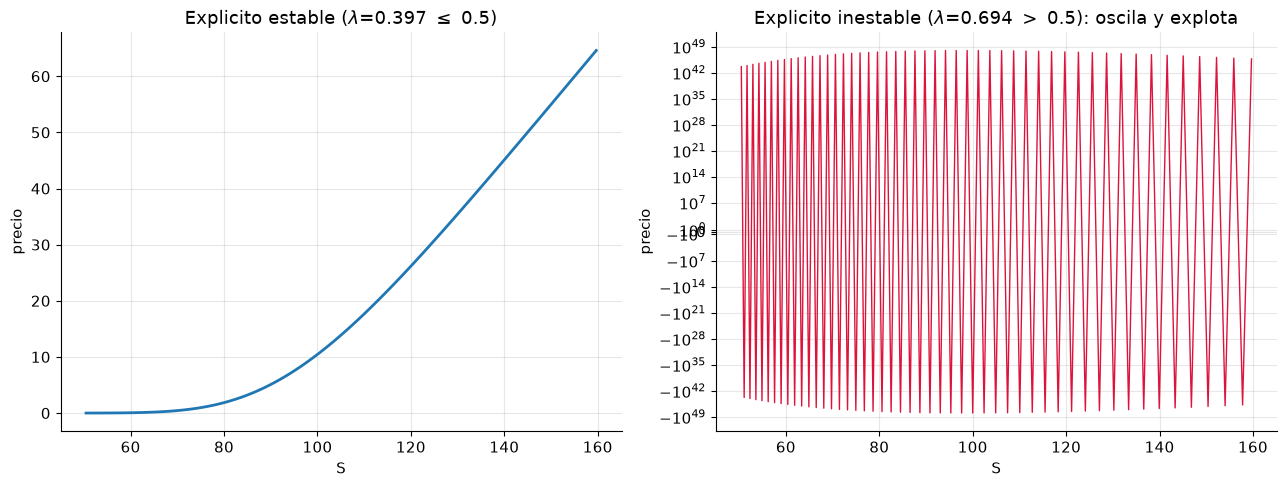

In [4]:
def diffusion_lambda(Nx, Nt, x_width=6.0):
    dx = (2 * x_width * sigma * np.sqrt(T)) / Nx
    dt = T / Nt
    return 0.5 * sigma**2 * dt / dx**2


Nx_cfl = 200
Nt_below, Nt_above = 350, 200   # Nt mas grande = dt mas chico = lambda mas chico
lam_below = diffusion_lambda(Nx_cfl, Nt_below)
lam_above = diffusion_lambda(Nx_cfl, Nt_above)

S_below, V_below = theta_scheme_call(Nx_cfl, Nt_below, theta=0.0)
S_above, V_above = theta_scheme_call(Nx_cfl, Nt_above, theta=0.0)

print(f"lambda = {lam_below:.4f} (Nt={Nt_below}, <= 0.5): max|V| = {np.max(np.abs(V_below)):.3e}, "
      f"finito = {np.all(np.isfinite(V_below))}")
print(f"lambda = {lam_above:.4f} (Nt={Nt_above}, >  0.5): max|V| = {np.max(np.abs(V_above)):.3e}, "
      f"finito = {np.all(np.isfinite(V_above))}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
mask_b = (S_below > 50) & (S_below < 160)
axes[0].plot(S_below[mask_b], V_below[mask_b], lw=2)
axes[0].set_xlabel("S"); axes[0].set_ylabel("precio")
axes[0].set_title(f"Explicito estable ($\\lambda$={lam_below:.3f} $\\leq$ 0.5)")

mask_a = (S_above > 50) & (S_above < 160)
axes[1].plot(S_above[mask_a], V_above[mask_a], lw=1, color="crimson")
axes[1].set_xlabel("S"); axes[1].set_ylabel("precio")
axes[1].set_yscale("symlog")
axes[1].set_title(f"Explicito inestable ($\\lambda$={lam_above:.3f} $>$ 0.5): oscila y explota")
plt.tight_layout()
plt.show()

## 4. Demo 3 — órdenes de convergencia, medidos lejos del kink

El kink en $S=K$ contamina cualquier medición ingenua del orden de convergencia: ahí el error no decae monótonamente con la malla, se comporta erráticamente porque la hipótesis de suavidad detrás del análisis de Taylor no se cumple en ese punto (4.6 trata esto en detalle, con la corrección de Rannacher). Por eso aquí medimos el **error máximo sobre la malla excluyendo una vecindad del strike** ($|S-K|>15$) — así se mide el orden genuino del esquema, no el artefacto del kink.

Fijando una malla espacial muy fina para aislar el error temporal, esperamos pendiente $\approx-1$ para el implícito y $\approx-2$ para Crank-Nicolson; fijando una malla temporal muy fina para aislar el error espacial, pendiente $\approx-2$ (las diferencias centradas son de segundo orden en cualquier $\theta$).

Convergencia temporal (Nx=6000 fijo, error lejos del kink):
     Nt | err implicito |        err CN
      8 |     8.911e-02 |     3.405e-03
     16 |     4.606e-02 |     8.618e-04
     32 |     2.342e-02 |     2.155e-04
     64 |     1.181e-02 |     5.415e-05
    128 |     5.931e-03 |     1.386e-05
  pendiente implicito = -0.978 (teoria -1) | pendiente CN = -1.987 (teoria -2)

Convergencia espacial CN (Nt=4000 fijo, error lejos del kink):
  Nx=  50: err=3.312e-02
  Nx= 100: err=8.286e-03
  Nx= 200: err=2.072e-03
  Nx= 400: err=5.180e-04
  Nx= 800: err=1.320e-04
  pendiente = -1.994 (teoria -2)


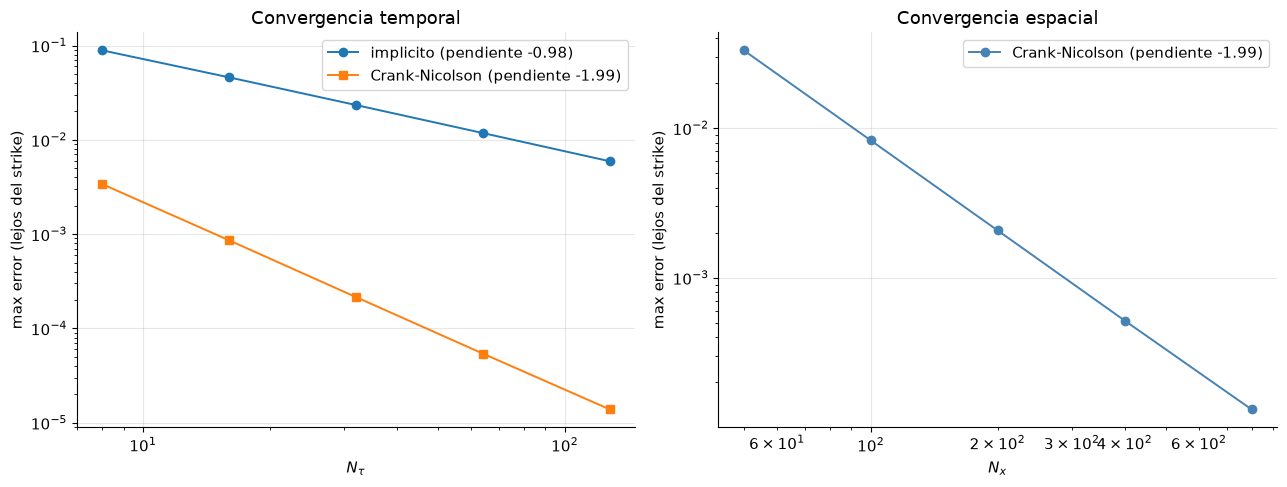

In [5]:
def max_error_away_from_strike(S, V, K, r, q, sigma, T, margin=15.0):
    ref = bs_call_grid(S, K, r, q, sigma, T)
    mask = np.abs(S - K) > margin
    return np.max(np.abs(V[mask] - ref[mask]))


Nt_grid = [8, 16, 32, 64, 128]
Nx_fine_for_time = 6000
errors_implicit_t, errors_cn_t = [], []
for Nt in Nt_grid:
    S_i, V_i = theta_scheme_call(Nx_fine_for_time, Nt, theta=1.0)
    S_c, V_c = theta_scheme_call(Nx_fine_for_time, Nt, theta=0.5)
    errors_implicit_t.append(max_error_away_from_strike(S_i, V_i, K, r, q, sigma, T))
    errors_cn_t.append(max_error_away_from_strike(S_c, V_c, K, r, q, sigma, T))
errors_implicit_t, errors_cn_t = np.array(errors_implicit_t), np.array(errors_cn_t)
slope_implicit_t = np.polyfit(np.log(Nt_grid), np.log(errors_implicit_t), 1)[0]
slope_cn_t = np.polyfit(np.log(Nt_grid), np.log(errors_cn_t), 1)[0]

Nx_grid = [50, 100, 200, 400, 800]
Nt_fine_for_space = 4000
errors_cn_x = []
for Nx in Nx_grid:
    S_s, V_s = theta_scheme_call(Nx, Nt_fine_for_space, theta=0.5)
    errors_cn_x.append(max_error_away_from_strike(S_s, V_s, K, r, q, sigma, T))
errors_cn_x = np.array(errors_cn_x)
slope_cn_x = np.polyfit(np.log(Nx_grid), np.log(errors_cn_x), 1)[0]

print(f"Convergencia temporal (Nx={Nx_fine_for_time} fijo, error lejos del kink):")
print(f"  {'Nt':>5} | {'err implicito':>13} | {'err CN':>13}")
for Nt, ei, ec in zip(Nt_grid, errors_implicit_t, errors_cn_t):
    print(f"  {Nt:>5} | {ei:>13.3e} | {ec:>13.3e}")
print(f"  pendiente implicito = {slope_implicit_t:.3f} (teoria -1) | pendiente CN = {slope_cn_t:.3f} (teoria -2)")

print(f"\nConvergencia espacial CN (Nt={Nt_fine_for_space} fijo, error lejos del kink):")
for Nx, ex in zip(Nx_grid, errors_cn_x):
    print(f"  Nx={Nx:>4}: err={ex:.3e}")
print(f"  pendiente = {slope_cn_x:.3f} (teoria -2)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(Nt_grid, errors_implicit_t, "o-", label=f"implicito (pendiente {slope_implicit_t:.2f})")
ax.plot(Nt_grid, errors_cn_t, "s-", label=f"Crank-Nicolson (pendiente {slope_cn_t:.2f})")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("$N_\\tau$"); ax.set_ylabel("max error (lejos del strike)")
ax.set_title("Convergencia temporal")
ax.legend()

ax = axes[1]
ax.plot(Nx_grid, errors_cn_x, "o-", color="steelblue", label=f"Crank-Nicolson (pendiente {slope_cn_x:.2f})")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("$N_x$"); ax.set_ylabel("max error (lejos del strike)")
ax.set_title("Convergencia espacial")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Demo 4 — el factor de amplificación, hecho figura

La teoría de von Neumann de la §3 se puede verificar directamente: para cada $\theta$ y $\lambda$, calculamos $|\xi(k)|$ analíticamente sobre el rango de números de onda $k\Delta x\in[0,\pi]$ (el máximo representable en la malla) y marcamos dónde cruza $1$.

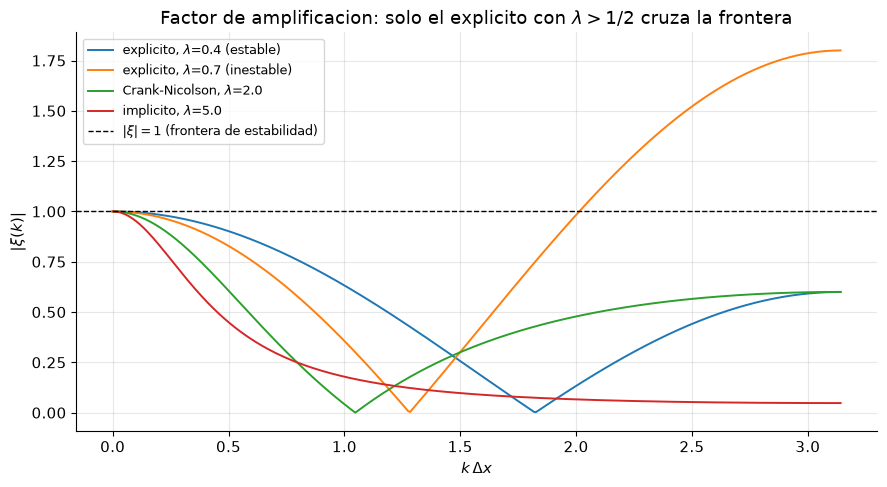

Verificacion: |xi| analitico vs simulacion directa de un modo de Fourier puro
  formula = 0.32269330 | un paso directo = 0.32269330 | diff = 0.00e+00


In [6]:
def amplification_factor(theta, lam, k_dx):
    '''|xi(k)| for the theta-scheme, diffusion-only approximation of Section 3.'''
    kappa = 4.0 * np.sin(k_dx / 2.0) ** 2
    numerator = 1.0 - (1.0 - theta) * lam * kappa
    denominator = 1.0 + theta * lam * kappa
    return numerator / denominator


k_dx_grid = np.linspace(1e-6, np.pi, 400)
fig, ax = plt.subplots(figsize=(9, 5))
for theta, lam, label in [(0.0, 0.4, "explicito, $\\lambda$=0.4 (estable)"),
                           (0.0, 0.7, "explicito, $\\lambda$=0.7 (inestable)"),
                           (0.5, 2.0, "Crank-Nicolson, $\\lambda$=2.0"),
                           (1.0, 5.0, "implicito, $\\lambda$=5.0")]:
    xi = amplification_factor(theta, lam, k_dx_grid)
    ax.plot(k_dx_grid, np.abs(xi), label=label)
ax.axhline(1.0, color="black", lw=1, ls="--", label="$|\\xi|=1$ (frontera de estabilidad)")
ax.set_xlabel("$k\\,\\Delta x$"); ax.set_ylabel("$|\\xi(k)|$")
ax.set_title("Factor de amplificacion: solo el explicito con $\\lambda>1/2$ cruza la frontera")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# verificacion numerica exacta de la formula de amplificacion
print("Verificacion: |xi| analitico vs simulacion directa de un modo de Fourier puro")
lam_test, theta_test, k_test = 0.3, 0.0, 1.7
xi_formula = amplification_factor(theta_test, lam_test, k_test)
# un paso del esquema explicito sobre u_j = cos(k*j), en malla periodica de referencia (sin fronteras)
n_pts = 64
j = np.arange(n_pts)
u0 = np.cos(k_test * j)
kappa = 4.0 * np.sin(k_test / 2.0) ** 2
u1 = u0 - theta_test * 0.0 + (1 - theta_test) * (-lam_test * kappa) * u0  # theta=0: u1=u0*(1+(1-theta)*dt*L)
xi_numeric = u1[5] / u0[5] if u0[5] != 0 else np.nan
print(f"  formula = {xi_formula:.8f} | un paso directo = {xi_numeric:.8f} | diff = {abs(xi_formula-xi_numeric):.2e}")

## 6. Validación

1. **Precio en toda la malla**: implícito y Crank-Nicolson contra Black-Scholes en $S_0$, `atol=5e-3` con $N_x=800,N_\tau=400$.
2. **Inestabilidad del explícito**: con $\lambda\leq0.5$ el esquema permanece acotado (`max|V| < 10^3`); con $\lambda>0.5$, diverge (`max|V| > 10^6` o no finito) — los dos signos de la condición CFL, verificados en vivo.
3. **Órdenes de convergencia**, medidos lejos del kink: implícito temporal en $[-1.15,-0.85]$; Crank-Nicolson temporal en $[-2.3,-1.7]$; Crank-Nicolson espacial en $[-2.3,-1.7]$.
4. **Factor de amplificación**: la fórmula analítica reproduce, a `atol=1e-10`, un paso directo del esquema sobre un modo de Fourier puro — la identidad algebraica detrás de todo el análisis de estabilidad.

In [7]:
# 1. Precio en toda la malla
err_impl_S0 = abs(V_implicit[idx_S0] - bs_on_grid[idx_S0])
err_cn_S0 = abs(V_cn[idx_S0] - bs_on_grid[idx_S0])
print(f"error implicito en S0 = {err_impl_S0:.5f} (atol 5e-3? {err_impl_S0 < 5e-3})")
print(f"error CN en S0        = {err_cn_S0:.5f} (atol 5e-3? {err_cn_S0 < 5e-3})")
assert err_impl_S0 < 5e-3
assert err_cn_S0 < 5e-3

# 2. Inestabilidad del explicito
print(f"\nlambda={lam_below:.3f} (<=0.5): max|V|={np.max(np.abs(V_below)):.2e} "
      f"(<1e3? {np.max(np.abs(V_below)) < 1e3})")
assert np.max(np.abs(V_below)) < 1e3
blew_up = (not np.all(np.isfinite(V_above))) or (np.max(np.abs(V_above)) > 1e6)
print(f"lambda={lam_above:.3f} (>0.5): explota? {blew_up}")
assert blew_up

# 3. Ordenes de convergencia
print(f"\npendiente implicito (temporal) = {slope_implicit_t:.3f} (en [-1.15,-0.85]? "
      f"{-1.15 <= slope_implicit_t <= -0.85})")
assert -1.15 <= slope_implicit_t <= -0.85
print(f"pendiente CN (temporal) = {slope_cn_t:.3f} (en [-2.3,-1.7]? {-2.3 <= slope_cn_t <= -1.7})")
assert -2.3 <= slope_cn_t <= -1.7
print(f"pendiente CN (espacial) = {slope_cn_x:.3f} (en [-2.3,-1.7]? {-2.3 <= slope_cn_x <= -1.7})")
assert -2.3 <= slope_cn_x <= -1.7

# 4. Factor de amplificacion: identidad algebraica
np.testing.assert_allclose(xi_formula, xi_numeric, atol=1e-10)
print(f"\n|xi| formula vs un paso directo: diff = {abs(xi_formula-xi_numeric):.2e} (atol 1e-10? True)")

print()
print("Validacion completa: 4/4 dentro de tolerancia.")

error implicito en S0 = 0.00283 (atol 5e-3? True)
error CN en S0        = 0.00020 (atol 5e-3? True)

lambda=0.397 (<=0.5): max|V|=2.37e+02 (<1e3? True)
lambda=0.694 (>0.5): explota? True

pendiente implicito (temporal) = -0.978 (en [-1.15,-0.85]? True)
pendiente CN (temporal) = -1.987 (en [-2.3,-1.7]? True)
pendiente CN (espacial) = -1.994 (en [-2.3,-1.7]? True)

|xi| formula vs un paso directo: diff = 0.00e+00 (atol 1e-10? True)

Validacion completa: 4/4 dentro de tolerancia.


## Referencias

- Wilmott, P., Howison, S. & Dewynne, J. (1995). *The Mathematics of Financial Derivatives*, Cambridge University Press, caps. 8-9.
- Duffy, D.J. (2006). *Finite Difference Methods in Financial Engineering: A Partial Differential Equation Approach*, Wiley, caps. 2-4.
- Tavella, D. & Randall, C. (2000). *Pricing Financial Instruments: The Finite Difference Method*, Wiley.
- Smith, G.D. (1985). *Numerical Solution of Partial Differential Equations: Finite Difference Methods*, 3rd ed., Oxford University Press, cap. 3 (análisis de von Neumann).
- Crank, J. & Nicolson, P. (1947). *A Practical Method for Numerical Evaluation of Solutions of Partial Differential Equations of the Heat-Conduction Type*. Proc. Cambridge Phil. Soc., 43(1), 50-67.